# Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    import wandb
except ImportError:
    wandb = None
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import print_mol_types
from src.data.graph_building import build_graph_features
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import mask_data, preprocess
from src.data.cleaning import fragment_count, is_salt, has_metal, is_single_node
from src.data.splitting_re import butina_split
from src.data.sampling import build_weighted_random_sampler, compute_attribute_distribution
from src.training.loops import train
from src.visualization.training_plots import plot_toxicity_distribution, plot_training


pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

print("Setup complete")
print(f"Data file: {DATA_PATH}")


/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete
Data file: /home/vollmers/gnn-thesis/Data/toxicity_all.csv


# Load And Filter Data


In [2]:
selected_columns = [
    'SK_unique_id',
    'species_common_name',
    'species_latin_name',
    'CAS',
    'chemical_name',
    'conc_unit',
    'conc',
    'duration',
    'duration_unit',
    'effect',
    'endpoint',
    'SMILES',
    'organism_lifestage_categorized',
    'administration_route_categorized',
    'NCBI_sci_name',
    'NCBI_last_known_rank',
    'NCBI_rank_superkingdom',
    'NCBI_rank_kingdom',
    'NCBI_rank_phylum',
    'NCBI_rank_subphylum',
    'NCBI_rank_class',
    'NCBI_rank_order',
    'NCBI_rank_family',
    'NCBI_rank_genus',
    'NCBI_rank_species',
    'species_group_corrected'
]

df_all = load_data(DATA_PATH, selected_columns)

df_all = df_all.rename(columns={
    'species_group_corrected': 'species_group',
    'organism_lifestage_categorized': 'organism_lifestage',
    'administration_route_categorized': 'administration_route'
})

# Rename columns starting with NCBI_ to be more concise
df_all = df_all.rename(columns={
    'NCBI_rank_superkingdom': 'superkingdom',
    'NCBI_rank_kingdom': 'kingdom',
    'NCBI_rank_phylum': 'phylum',
    'NCBI_rank_subphylum': 'subphylum',
    'NCBI_rank_class': 'class',
    'NCBI_rank_order': 'order',
    'NCBI_rank_family': 'family',
    'NCBI_rank_genus': 'genus',
    'NCBI_rank_species': 'species',
    'NCBI_sci_name': 'species_sci_name',
    'NCBI_last_known_rank': 'taxid'
})

print(df_all['duration'].value_counts())

# Fill missing organimsm_lifestage -> adult, administration_route -> fill, duration_unit -> h
df_all['organism_lifestage'] = df_all['organism_lifestage'].fillna('adult')
df_all['administration_route'] = df_all['administration_route'].fillna('fill')
df_all['duration_unit'] = df_all['duration_unit'].fillna('h')

# Filters
filters = {
    # "conc_unit": ["mg/L"],
    "duration_unit": ["h"],
    # "endpoint": ["EC50"],
    "effect": ["MOR", "POP", "GRO", "BEH", "REP", "ITX", "PHY", "DVP", "MPH"],
}
require_duration = False
require_taxonomy = True

taxonomy_cols = (
    "class",
    "family",
    "genus",
    "species",
)

# Create mask
mask = mask_data(
    df_all,
    filters=filters,
    require_duration=require_duration,
    require_taxonomy=require_taxonomy,
    taxonomy_columns=taxonomy_cols,
)

# Apply mask and filter
df_filtered = df_all.loc[mask].copy()

# Convert taxonomy columns to numeric, coercing errors to NaN and then to nullable Int64
for col in taxonomy_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors="coerce").astype("Int64")

print()
print("Loaded and filtered training data")
print(f"Rows in full data: {len(df_all):,}")
print(f"Rows after filter: {len(df_filtered):,}")
print()
print("Filtered preview")
print(df_filtered.head())


duration
96.00       64216
48.00       55824
24.00       45443
72.00       30372
168.00      19659
            ...  
219.36          1
510.24          1
301.68          1
51840.00        1
59040.00        1
Name: count, Length: 2309, dtype: int64
Filters
duration_unit: ['h']
True: 0.980
effect: ['MOR', 'POP', 'GRO', 'BEH', 'REP', 'ITX', 'PHY', 'DVP', 'MPH']
True: 0.981
require_taxonomy: True
True: 0.916

Loaded and filtered training data
Rows in full data: 561,100
Rows after filter: 495,422

Filtered preview
  SK_unique_id species_common_name species_latin_name          CAS  \
0       RTECS7               mouse       Mus musculus  108073-64-9   
1      RTECS41               mouse       Mus musculus   78111-17-8   
2     RTECS137               mouse       Mus musculus    4657-93-6   
3     RTECS140               mouse       Mus musculus  102585-20-6   
4     RTECS141                 rat  Rattus norvegicus      83-32-9   

                                                                 

# Preprocess Molecules And Targets


In [3]:
# Cut dataset for faster experiments
MAX_ROWS = 6000  # set to an integer like 15000 for faster experiments
# MAX_ROWS = None
random_state = 11

# Optionally limit the number of rows for faster experiments
if MAX_ROWS is not None and len(df_filtered) > MAX_ROWS:
    df_filtered = df_filtered.sample(n=MAX_ROWS, random_state=random_state).reset_index(drop=True)
else:
    df_filtered = df_filtered.reset_index(drop=True)


# Preprocess data
SPLIT_SALTS = False
REMOVE_LONE = False
REMOVE_METALS = False

MAX_CONC_VALUE = 10000
DURATION_FILL_VALUE = 1e-6
MAX_DURATION_HOURS = 9000.0
LOG_TRANSFORM_DURATION = True

df_processed = preprocess(
    df_filtered.copy(),
    split_salts=False,
    remove_lone=False,
    remove_metals=False,
    max_conc_value=MAX_CONC_VALUE,
    duration_fill_value=DURATION_FILL_VALUE,
    max_duration_hours=MAX_DURATION_HOURS,
    log_transform_duration=True,
    keep_duration_raw=True,
)

print(f"Rows before preprocessing: {len(df_filtered):,}")
print(f"Rows after preprocessing:  {len(df_processed):,}")
print(f"Rows removed: {len(df_filtered) - len(df_processed):,}")
print()
print("Preprocessed preview")
print(df_processed[["SMILES", "duration_raw", "duration", "conc", "log10c", "species_group"]].head())
print()
print_mol_types(df_processed)


Rows before preprocessing: 6,000
Rows after preprocessing:  5,886
Rows removed: 114

Preprocessed preview
                                   SMILES  duration_raw  duration        conc  \
0                              [F-].[Na+]          96.0  1.982271  272.000000   
1     COc1cc(OC)nc(Sc2cccc(Cl)c2C(=O)O)n1         504.0  2.702431    0.000007   
2                                       S          96.0  1.982271    0.063000   
3  O=[N+]([O-])c1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl          96.0  1.982271    1.500000   
4                       CCCN(CCC)C(=O)SCC         672.0  2.827369    0.000100   

     log10c species_group  
0  2.434569         algae  
1 -5.148742        plants  
2 -1.200659   crustaceans  
3  0.176091          fish  
4 -4.001062        plants  

Total molecules: 5886
Unique molecules: 2932
Disconnected species: 1450, 24.63%
Single-node species: 110, 1.87%
Metals: 1115, 18.94%


# Encoding Data

## Featiruze molecules

In [4]:
from src.data.featurization import simple_featurizer

# df_processed["features"] = df_processed["SMILES"].apply(from_smiles)

# atom_features = ["atomic_num", "mass"]
# bond_features = ["bond_order"]
df_processed["features"] = df_processed["SMILES"].apply(simple_featurizer)

sample_id = min(16, len(df_processed) - 1)

print()
print(f"{len(df_processed):,} rows with graph features created")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'


Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'
[13:40:59] WARNING: not removing hydrogen atom without neighbors
[13:40:59] WARNING: not removing hydrogen atom without neighbors
[13:40:59] WARNING: not removing hydrogen atom without neighbors
[13:40:59] WARNING: not removing hydrogen atom without neighbors
[13:40:59] WARNING: not removing hydrogen atom without neighbors
[13:40:59] WARNING: not removing hydrogen atom without neighbors
[13:40:59] WARNING: not removing hydrogen atom without neighbors
[13:40:


5,886 rows with graph features created


## Taxonomy Encoding

In [5]:
USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = "../Data/moredata/pretrained_tax_emb.pkl.zip"

tax_embedding = {
    "taxid": 16,
    "species_group": 16,
    # "genus": 8,
    # "family": 8,
    # "class": 4,
}

# Remove taxid from embedding if using pretrained taxid embeddings
model_tax_embedding = (
    {key: value for key, value in tax_embedding.items() if key != "taxid"}
    if USE_PRETRAINED_TAXID
    else tax_embedding
)

df_tax = df_processed[list(tax_embedding.keys())].copy()
df_tax, encoders = sequential_encoder(df_tax, tax_embedding.keys())
# df_tax now contains only the sequential data for selected columns

config_tax = build_config(df_tax, model_tax_embedding)
taxid_decoder = {encoded: original for original, encoded in encoders["taxid"].items()}
taxid_lookup = (
    df_processed[["taxid", "species_sci_name"]]
    .dropna(subset=["taxid", "species_sci_name"])
    .drop_duplicates(subset=["taxid"])
    .set_index("taxid")["species_sci_name"]
    .to_dict()
)

species_decoder = {encoded: original for original, encoded in encoders["species_group"].items()}


if not USE_PRETRAINED_TAXID:
    print("Don't use pretrained taxid embeddings")
    print("Taxonomy embedding config")
    print(config_tax)


if USE_PRETRAINED_TAXID:
    print(f"Use pretrained taxid embeddings")
    print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

Use pretrained taxid embeddings
Pretrained taxid path: ../Data/moredata/pretrained_tax_emb.pkl.zip


## Categorical and Numerical Encoding

In [6]:
# Add some more metadata cols
df_processed["fragment_count"] = df_processed["SMILES"].apply(fragment_count).astype(float)
df_processed["is_salt"] = df_processed["SMILES"].apply(is_salt).astype(float)
df_processed["has_metal"] = df_processed["SMILES"].apply(has_metal).astype(float)
df_processed["is_single_node"] = df_processed["SMILES"].apply(is_single_node).astype(float)

# Categorical encoding
categorical_cols = [
    "conc_unit",
    "endpoint", 
    "effect", 
    "is_salt",
    "has_metal",
    "is_single_node"
    ]

df_categorical = df_processed[categorical_cols].copy()
df_categorical, categorical_encoders = sequential_encoder(df_categorical, categorical_cols)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, categorical_cols)

print("Categorical embedding config:")
print(config_categorical)
print()

# Numerical encoding 
numerical_cols = [
    "duration",
    "fragment_count",
    # "is_salt",
    # "has_metal",
    # "is_single_node",
]

print("Numerical encoding for:")
print(numerical_cols)


Categorical embedding config:
{'conc_unit': 14, 'endpoint': 4, 'effect': 9, 'is_salt': 2, 'has_metal': 2, 'is_single_node': 2}

Numerical encoding for:
['duration', 'fragment_count']


# Build The Final Graph Dataset


In [7]:
features = build_graph_features(
    df_processed, 
    df_tax, 
    tax_embedding, 
    df_categorical,
    categorical_cols,
    numerical_cols
    )

sample_feature = features[sample_id]

print(f"Graph objects created: {len(features):,}")
print()
print("Info for a sample:")
print(features[sample_id])


Graph objects created: 5,886

Info for a sample:
Data(x=[10, 7], edge_index=[2, 18], edge_attr=[18, 3], smiles='CSC1=NCCCCN1.I', y=1.7481880187988281, row_id=16, taxid=5, species_group=4, taxid_raw=10090, conc_unit=3, endpoint=0, effect=1, is_salt=0, has_metal=1, is_single_node=0, duration=-6.0, fragment_count=2.0)


# Prepare for training

## Split data

Using csv file for butina splitting: ../Data/moredata/original/butina_cluster_lookup.csv
Using stratified splitting with stratify_by: ['species_group', 'endpoint', 'effect']
Split method: butina
Train size: 4,120 (70.0%)
Val size:   1,177 (20.0%)
Test size:  589 (10.0%)

Unique molecules in train: 2,685
Unique molecules in val:   219
Unique molecules in test:  28
Val molecules not in train:  219
Test molecules not in train: 28

Target distribution
Train mean/std: 0.5789 / 2.3379
Val mean/std:   -0.2747 / 2.1894
Test mean/std:  -0.7083 / 2.2954


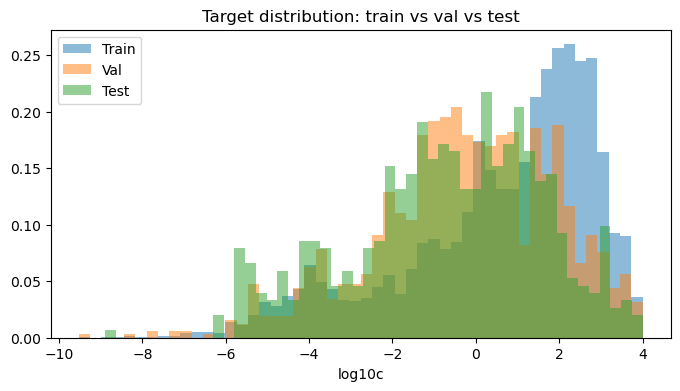

In [ ]:
split_method = "butina"
cluster_col = "Cluster_at_cutoff_0.2"
stratify_by = ["species_group", "endpoint", "effect"]
frac_train = 0.7
frac_valid = 0.1
frac_test = 0.2
cluster_csv_path = "../Data/moredata/original/butina_cluster_lookup.csv"

train_dataset, val_dataset, test_dataset = butina_split(
    features,
    frac_train=frac_train,
    frac_test=frac_test,
    frac_valid=frac_valid,
    cluster_csv_path=cluster_csv_path,
    cluster_col=cluster_col,
    stratify_by=stratify_by
)

train_targets = np.array([g.y.item() for g in train_dataset])
val_targets = np.array([g.y.item() for g in val_dataset])
test_targets = np.array([g.y.item() for g in test_dataset])
train_smiles = [g.smiles for g in train_dataset]
val_smiles = [g.smiles for g in val_dataset]
test_smiles = [g.smiles for g in test_dataset]

print(f"Split method: {split_method}")
print(f"Train size: {len(train_dataset):,} ({len(train_dataset) / len(features):.1%})")
print(f"Val size:   {len(val_dataset):,} ({len(val_dataset) / len(features):.1%})")
print(f"Test size:  {len(test_dataset):,} ({len(test_dataset) / len(features):.1%})")
print()
print(f"Unique molecules in train: {len(set(train_smiles)):,}")
print(f"Unique molecules in val:   {len(set(val_smiles)):,}")
print(f"Unique molecules in test:  {len(set(test_smiles)):,}")
print(f"Val molecules not in train:  {len(set(val_smiles) - set(train_smiles)):,}")
print(f"Test molecules not in train: {len(set(test_smiles) - set(train_smiles)):,}")
print()
print("Target distribution")
print(f"Train mean/std: {train_targets.mean():.4f} / {train_targets.std():.4f}")
print(f"Val mean/std:   {val_targets.mean():.4f} / {val_targets.std():.4f}")
print(f"Test mean/std:  {test_targets.mean():.4f} / {test_targets.std():.4f}")

plot_toxicity_distribution(train_dataset, test_dataset, val_dataset=val_dataset)


## Build DataLoaders


In [10]:
batch_size = 256
use_species_ratio_sampler = True
# Eval samplers use replacement, so validation/test metrics become stochastic when enabled.
apply_species_ratio_sampler_to_eval = False
species_sampler_attribute = "species_group"
sampler_replacement = True

species_target_distribution = compute_attribute_distribution(features, species_sampler_attribute)
train_species_distribution = compute_attribute_distribution(train_dataset, species_sampler_attribute)
val_species_distribution = compute_attribute_distribution(val_dataset, species_sampler_attribute)
test_species_distribution = compute_attribute_distribution(test_dataset, species_sampler_attribute)

train_sampler = None
val_sampler = None
test_sampler = None

if use_species_ratio_sampler:
    train_sampler = build_weighted_random_sampler(
        train_dataset,
        attribute_name=species_sampler_attribute,
        target_distribution=species_target_distribution,
        replacement=sampler_replacement,
    )

    if apply_species_ratio_sampler_to_eval:
        val_sampler = build_weighted_random_sampler(
            val_dataset,
            attribute_name=species_sampler_attribute,
            target_distribution=species_target_distribution,
            replacement=sampler_replacement,
        )
        test_sampler = build_weighted_random_sampler(
            test_dataset,
            attribute_name=species_sampler_attribute,
            target_distribution=species_target_distribution,
            replacement=sampler_replacement,
        )

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=train_sampler is None,
    sampler=train_sampler,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    sampler=val_sampler,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    sampler=test_sampler,
)

species_ratio_summary = (
    pd.DataFrame(
        {
            "target_ratio": pd.Series(species_target_distribution),
            "train_ratio": pd.Series(train_species_distribution),
            "val_ratio": pd.Series(val_species_distribution),
            "test_ratio": pd.Series(test_species_distribution),
        }
    )
    .fillna(0.0)
    .rename_axis(species_sampler_attribute)
    .reset_index()
)
species_ratio_summary["max_split_gap"] = (
    species_ratio_summary[["train_ratio", "val_ratio", "test_ratio"]]
    .sub(species_ratio_summary["target_ratio"], axis=0)
    .abs()
    .max(axis=1)
)

first_batch = next(iter(train_loader))

print(f"Batch size: {batch_size}")
print(f"Species sampler enabled: {use_species_ratio_sampler}")
print(f"Eval samplers enabled: {apply_species_ratio_sampler_to_eval}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print()
print(f"Largest {species_sampler_attribute} ratio gaps before sampling")
species_ratio_summary_display = species_ratio_summary.copy()
species_ratio_summary_display["species_group_label"] = (
    species_ratio_summary_display[species_sampler_attribute]
    .map(species_decoder)
    .fillna("Missing")
)

display(
    species_ratio_summary_display
    .sort_values(["max_split_gap", "target_ratio"], ascending=[False, False])
    .head(10)[
        [
            "species_group_label",
            "target_ratio",
            "train_ratio",
            "val_ratio",
            "test_ratio",
            "max_split_gap",
        ]
    ]
)
print()
print("First batch summary")
print(f"Graphs in batch: {first_batch.num_graphs}")
print(f"x shape: {tuple(first_batch.x.shape)}")
print(f"edge_index shape: {tuple(first_batch.edge_index.shape)}")
print(f"edge_attr shape: {tuple(first_batch.edge_attr.shape)}")
print(f"y shape: {tuple(first_batch.y.shape)}")


Batch size: 256
Species sampler enabled: True
Eval samplers enabled: False
Train batches per epoch: 17
Val batches: 5
Test batches: 3

Largest species_group ratio gaps before sampling


,species_group_label,target_ratio,train_ratio,val_ratio,test_ratio,max_split_gap
4,rodents,0.282365,0.378155,0.059473,0.057725,0.224640
7,insects,0.116038,0.098786,0.132540,0.203735,0.087697
3,fish,0.178729,0.159223,0.242141,0.188455,0.063412
2,crustaceans,0.123683,0.104126,0.172472,0.162988,0.048789
8,mollusks,0.024975,0.011650,0.053526,0.061121,0.036146
9,worms,0.027353,0.017233,0.046729,0.059423,0.032070
6,amphibians,0.017329,0.007524,0.037383,0.045840,0.028511
0,algae,0.062012,0.066990,0.053526,0.044143,0.017869
10,rotifers,0.004587,0.001214,0.015293,0.006791,0.010706
11,cyanobacteria,0.005776,0.002670,0.015293,0.008489,0.009517



First batch summary
Graphs in batch: 256
x shape: (4726, 7)
edge_index shape: (2, 9558)
edge_attr shape: (9558, 3)
y shape: (256,)


# Model and training


## Build model

In [11]:
from src.models.attentive_fp import AttentiveFP
from src.models.afp_flex import AFPFlex
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder, TaxonomyEncoder, TaxonomyOneHot

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TAX_DIM = 32
PRETRAINED_TAX_DIM = 768 # 768 is the length of the vectors in pretrained_tax_emb.pkl.zip
PRETRAINED_TAXID_OUTPUT_DIM = 128
CATEGORICAL_DIM = 32
NUMERIC_DIM = 32
META_DROPOUT = 0.3

GNN_HIDDEN_DIM = 128
GNN_OUT_DIM = 128

NUM_LAYERS = 3
NUM_TIMESTEPS = 2
DROPOUT = 0.4

FINAL_HIDDEN_DIM = 256

ATOM_FEATURE_DIM = features[0].x.shape[1]
EDGE_FEATURE_DIM = features[0].edge_attr.shape[1]

meta_encoder = MetaEncoder(
    taxonomy_encoder_cls=TaxonomyOneHot,
    config_tax=config_tax,
    tax_output_dim=TAX_DIM,
    pretrained_taxid_path=PRETRAINED_TAXID_PATH if USE_PRETRAINED_TAXID else None,
    pretrained_tax_dim=PRETRAINED_TAX_DIM,
    pretrained_taxid_output_dim=PRETRAINED_TAXID_OUTPUT_DIM,
    config_categorical=config_categorical,
    categorical_output_dim=CATEGORICAL_DIM,
    numerical_columns=numerical_cols,
    numeric_output_dim=NUMERIC_DIM,
    dropout=META_DROPOUT
).to(device)


model_gnn = AFPFlex(
    in_channels=ATOM_FEATURE_DIM,
    edge_dim=EDGE_FEATURE_DIM,
    hidden_channels=GNN_HIDDEN_DIM,
    out_channels=GNN_OUT_DIM,
    num_layers=NUM_LAYERS,
    num_timesteps=NUM_TIMESTEPS,
    dropout=DROPOUT,
).to(device)

model = ToxicityModel(
    model_gnn,
    meta_encoder,
    hidden_dim=FINAL_HIDDEN_DIM,
).to(device)

n_params_meta = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad)
n_params_gnn = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad)
n_params_total = sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"Device: {device}")
print(f"Meta encoder trainable parameters: {n_params_meta:,}")
print(f"GNN trainable parameters: {n_params_gnn:,}")
print(f"Total trainable parameters: {n_params_total:,}")
print()
print(model)


Device: cpu
Meta encoder trainable parameters: 692,352
GNN trainable parameters: 514,176
Total trainable parameters: 1,297,665

ToxicityModel(
  (gnn): AFPFlex(
    (lin1): Linear(in_features=7, out_features=128, bias=True)
    (gate_conv): GATEConv()
    (gru): GRUCell(128, 128)
    (atom_convs): ModuleList(
      (0-1): 2 x GATConv(128, 128, heads=1)
    )
    (atom_grus): ModuleList(
      (0-1): 2 x GRUCell(128, 128)
    )
    (mol_conv): GATConv(128, 128, heads=1)
    (mol_gru): GRUCell(128, 128)
    (linlone): Linear(in_features=128, out_features=128, bias=True)
    (lin2): Linear(in_features=128, out_features=128, bias=True)
  )
  (meta_encoder): MetaEncoder(
    (tax_encoder): TaxonomyOneHot(
      (projection): Sequential(
        (0): Linear(in_features=18, out_features=32, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.3, inplace=False)
      )
    )
    (categorical_encoder): CategoricalOneHot(
      (projection): Sequential(
        (0): Linear(in_features=33, out

## Train The Model


wandb not installed; running without experiment tracking.
Training configuration
epochs = 100
learning_rate = 0.0003
weight_decay = 0.0001
loss = SmoothL1Loss
early_stopping_patience = 30


Epoch 76/100:  75%|███████▌  | 75/100 [01:24<00:28,  1.12s/epoch, train_loss=0.6946, val_loss=1.0777, val_rmse=1.6760, val_mae=1.3065, test_loss=1.2125, test_rmse=1.8503, test_mae=1.4884, lr=3.75e-05]

Early stopping at epoch 75: no improvement in val_loss for 30 epochs.


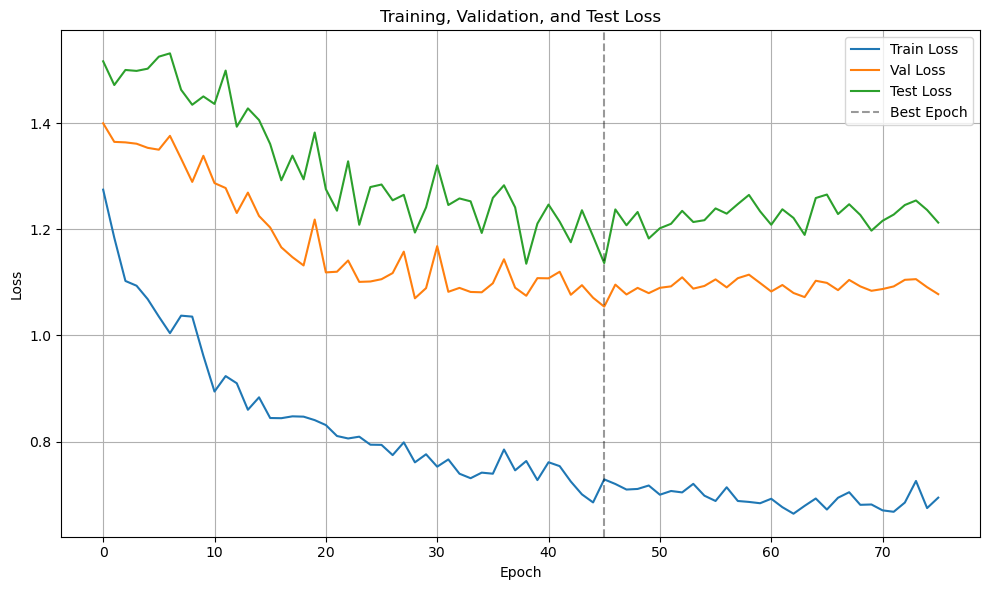

In [12]:
epochs = 100
learning_rate = 3e-4
weight_decay = 1e-4
loss_beta = 0.5
early_stopping_patience = 30
early_stopping_min_delta = 1e-4

loss_fn = torch.nn.SmoothL1Loss(beta=loss_beta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
    min_lr=1e-6,
)

USE_WANDB = wandb is not None  # set to False to skip tracking
USE_WANDB = False  # set to False to skip tracking
wandb_run = None

if USE_WANDB:
    wandb_run = wandb.init(
        project="gnn-thesis",
        entity="elonvg-chalmers-university-of-technology",
        job_type="train",
        tags=["notebook", split_method, type(model_gnn).__name__],
        config={
            "random_state": random_state,
            "n_samples": MAX_ROWS,

            "filters": filters,
            "split_salt": SPLIT_SALTS,
            "remove_lone": REMOVE_LONE,
            "remove_metals": REMOVE_METALS,
            "max_conc_value": MAX_CONC_VALUE,
            "duration_fill_value": DURATION_FILL_VALUE,
            "max_duration_hours": MAX_DURATION_HOURS,
            "log_transform_duration": LOG_TRANSFORM_DURATION,

            "num_atom_features": ATOM_FEATURE_DIM,
            "num_bond_features": EDGE_FEATURE_DIM,

            "tax_embedding": tax_embedding,
            "use_pretrained_taxid": USE_PRETRAINED_TAXID,
            "categorical_cols": categorical_cols,
            "numerical_cols": numerical_cols,

            "split_method": split_method,
            "butina_cluster_col": cluster_col,
            "frac_train": frac_train,
            "frac_valid": frac_valid,
            "frac_test": frac_test,
            # "target_mean": float(target_mean),
            # "target_std": float(target_std),

            "batch_size": batch_size,
            "taxonomy_encoder": TaxonomyOneHot.__name__,
            "gnn_model": type(model_gnn).__name__,
            "tax_dim": TAX_DIM,
            "pretrained_tax_dim": PRETRAINED_TAX_DIM,
            "pretrained_taxid_output_dim": PRETRAINED_TAXID_OUTPUT_DIM,
            "categorical_dim": CATEGORICAL_DIM,
            "numeric_dim": NUMERIC_DIM,
            "meta_dropout": META_DROPOUT,
            "gnn_hidden_dim": GNN_HIDDEN_DIM,
            "gnn_out_dim": GNN_OUT_DIM,
            "num_layers": NUM_LAYERS,
            "num_timesteps": NUM_TIMESTEPS,
            "dropout": DROPOUT,
            "final_hidden_dim": FINAL_HIDDEN_DIM,
            "n_params_meta": n_params_meta,
            "n_params_gnn": n_params_gnn,
            "n_params_total": n_params_total,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "loss": loss_fn.__class__.__name__,
            "loss_beta": loss_beta,
            "early_stopping_patience": early_stopping_patience,
            "early_stopping_min_delta": early_stopping_min_delta,
        },
    )
    wandb_run.define_metric("epoch")
    for metric_prefix in ("train/*", "val/*", "test/*", "optimizer/*"):
        wandb_run.define_metric(metric_prefix, step_metric="epoch")
else:
    print("wandb not installed; running without experiment tracking.")

print("Training configuration")
print(f"epochs = {epochs}")
print(f"learning_rate = {learning_rate}")
print(f"weight_decay = {weight_decay}")
print(f"loss = {loss_fn.__class__.__name__}")
print(f"early_stopping_patience = {early_stopping_patience}")

model_trained, history = train(
    model,
    train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=epochs,
    device=device,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    run=wandb_run,
)

model = model_trained
plot_training(history)


# Results

## Check Overall Test Performance

In [28]:
from src.training.loops import predict_df
from src.visualization.result_plots import summarize_by_group, plot_group_mae

analysis_df = df_processed.reset_index(drop=True)[[
    "species_group",
    "species_sci_name",
    "endpoint",
    "effect",
    "fragment_count",
    "has_metal",
    "is_single_node",
    "conc_unit"
]].copy()
analysis_df = analysis_df.rename(columns={"species_sci_name": "species_latin_name"})
analysis_df["fragment_bin"] = pd.cut(analysis_df["fragment_count"], [-1, 1, 2, np.inf], labels=["1", "2", "3+"])
analysis_df["has_metal_group"] = analysis_df["has_metal"].map({0.0: "No metal", 1.0: "Has metal"})
analysis_df["is_single_group"] = analysis_df["is_single_node"].map({0.0: "Not single-node", 1.0: "Single-node"})

results_df = predict_df(model, test_loader, device, cols=["row_id", "smiles", "taxid_raw"])
results_df["row_id"] = results_df["row_id"].astype(int)
results_df["taxid"] = results_df["taxid_raw"].astype(int)
results_df = results_df.drop(columns="taxid_raw").join(analysis_df, on="row_id")

results_df["pred_log10c"] = results_df["pred_norm"] # * target_std + target_mean
results_df["actual_log10c"] = results_df["actual_norm"] # * target_std + target_mean
results_df["residual_log10c"] = results_df["pred_log10c"] - results_df["actual_log10c"]
results_df["abs_error_log10c"] = results_df["residual_log10c"].abs()
results_df["pred_conc"] = 10 ** results_df["pred_log10c"]
results_df["actual_conc"] = 10 ** results_df["actual_log10c"]
results_df["fold_error"] = np.maximum(
    results_df["pred_conc"] / results_df["actual_conc"],
    results_df["actual_conc"] / results_df["pred_conc"],
)

train_df = analysis_df.iloc[[g.row_id.item() for g in train_dataset]].copy()

summary_metrics = {
    "test/r2_norm": r2_score(results_df["actual_norm"], results_df["pred_norm"]),
    "test/r2_log10c": r2_score(results_df["actual_log10c"], results_df["pred_log10c"]),
    "test/rmse_log10c": mean_squared_error(results_df["actual_log10c"], results_df["pred_log10c"]) ** 0.5,
    "test/mae_log10c": mean_absolute_error(results_df["actual_log10c"], results_df["pred_log10c"]),
    "test/median_fold_error": results_df["fold_error"].median(),
}

print("Overall test-set metrics")
print(f"R^2 (normalized target): {summary_metrics['test/r2_norm']:.3f}")
print(f"R^2 (log10c): {summary_metrics['test/r2_log10c']:.3f}")
print(f"RMSE (log10c): {summary_metrics['test/rmse_log10c']:.3f}")
print(f"MAE (log10c): {summary_metrics['test/mae_log10c']:.3f}")
print(f"Median fold error (conc scale): {summary_metrics['test/median_fold_error']:.3f}")

if wandb_run is not None:
    wandb_run.summary.update(summary_metrics)

    predictions_for_wandb = results_df[[
        "row_id",
        "smiles",
        "taxid",
        "species_latin_name",
        "species_group",
        "endpoint",
        "effect",
        "fragment_bin",
        "has_metal_group",
        "is_single_group",
        "actual_norm",
        "pred_norm",
        "actual_log10c",
        "pred_log10c",
        "residual_log10c",
        "abs_error_log10c",
        "fold_error",
    ]].copy()
    predictions_for_wandb["fragment_bin"] = predictions_for_wandb["fragment_bin"].astype(str)
    wandb_run.log({"predictions/test": wandb.Table(dataframe=predictions_for_wandb)})

largest_errors = results_df[[
    "species_latin_name",
    "species_group",
    "endpoint",
    "effect",
    "actual_log10c",
    "pred_log10c",
    "abs_error_log10c",
    "fold_error",
    "smiles",
]].sort_values("abs_error_log10c", ascending=False).head(10)

largest_errors


Overall test-set metrics
R^2 (normalized target): 0.616
R^2 (log10c): 0.616
RMSE (log10c): 1.372
MAE (log10c): 1.025
Median fold error (conc scale): 6.078


,species_latin_name,species_group,endpoint,effect,actual_log10c,pred_log10c,abs_error_log10c,fold_error,smiles
4658,caenorhabditis elegans,worms,EC10,BEH,-6.449772,1.882144,8.331916,2.147414e+08,Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1
7038,macrobrachium rosenbergii,crustaceans,EC50,MOR,-6.552842,1.484448,8.037291,1.089658e+08,COP(N)(=O)SC
1864,daphnia magna,crustaceans,NOEC,GRO,-9.522879,-1.678095,7.844783,6.994932e+07,CCC(C)C1OC2(CCC1C)CC1CC(CC=C(C)C(OC3CC(OC)C(OC4CC(OC)C(O)C(C)O4)C(C)O3)C(C)C...
1897,daphnia magna,crustaceans,NOEC,MOR,-9.000000,-1.518448,7.481552,3.030760e+07,CCC(C)C1OC2(CCC1C)CC1CC(CC=C(C)C(OC3CC(OC)C(OC4CC(OC)C(O)C(C)O4)C(C)O3)C(C)C...
4370,brassica rapa,plants,EC10,GRO,-6.283997,0.690424,6.974420,9.428012e+06,CCCCOC(=O)c1ccccc1C(=O)OCCCC
6588,acrobeloides nanus,worms,NOEC,REP,-5.943095,1.008810,6.951905,8.951698e+06,COC(=O)Nc1nc2ccccc2[nH]1
4670,caenorhabditis elegans,worms,EC10,BEH,-5.275724,1.665378,6.941102,8.731755e+06,Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1
4653,caenorhabditis elegans,worms,EC10,BEH,-4.943095,1.775911,6.719006,5.236078e+06,Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1
4323,trifolium repens,plants,EC10,GRO,-6.481486,0.121414,6.602900,4.007746e+06,CCCCOC(=O)c1ccccc1C(=O)OCCCC
73,eudrilus eugeniae,worms,EC50,MOR,-5.023650,1.553045,6.576695,3.773074e+06,CNC(=O)Oc1cccc2ccccc12


## Visual Result Checks

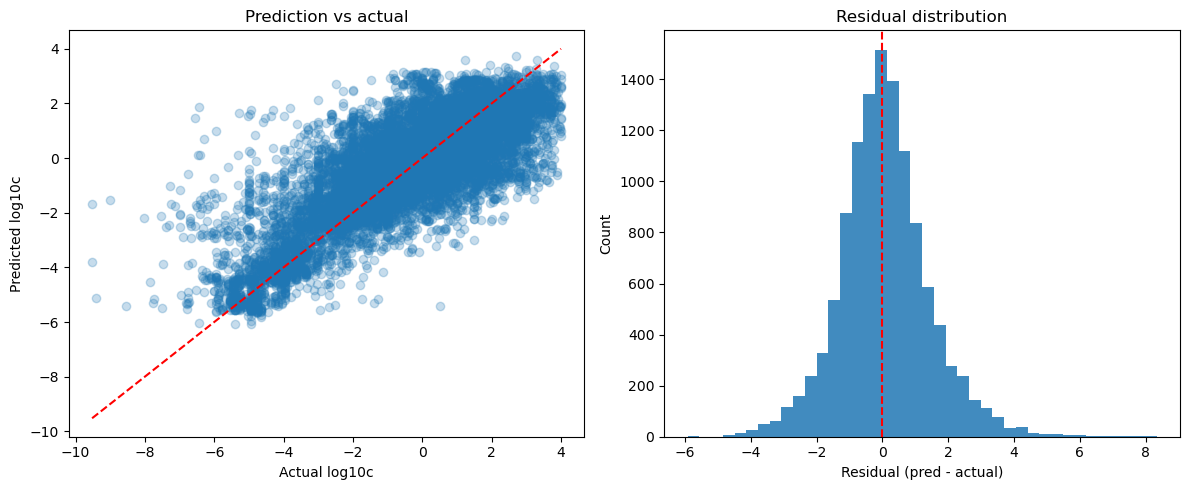

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["actual_log10c"], results_df["pred_log10c"], alpha=0.25)
plot_min = min(results_df["actual_log10c"].min(), results_df["pred_log10c"].min())
plot_max = max(results_df["actual_log10c"].max(), results_df["pred_log10c"].max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set_xlabel("Actual log10c")
axes[0].set_ylabel("Predicted log10c")
axes[0].set_title("Prediction vs actual")

axes[1].hist(results_df["residual_log10c"], bins=40, alpha=0.85)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred - actual)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


## Performance By Group

Conc Unit


,group,n,model_mae,baseline_mae,mae_gain
0,mg/L,7428,1.076500,1.447749,0.371249
1,ppm,1196,1.178893,1.410526,0.231633
2,kg/m2,1146,0.623350,0.725645,0.102295
3,mg/kg,588,0.909653,0.926827,0.017174
4,%,296,0.859907,1.000232,0.140325
5,mg/kg bw,283,0.756863,1.216683,0.459821
6,mg/kg soil,264,1.087105,1.167259,0.080154
7,mg/kg bw/d,248,0.790132,0.911885,0.121753
8,mg/org,180,1.527312,1.635406,0.108094
9,mg/kg diet,93,1.164282,1.021145,-0.143137


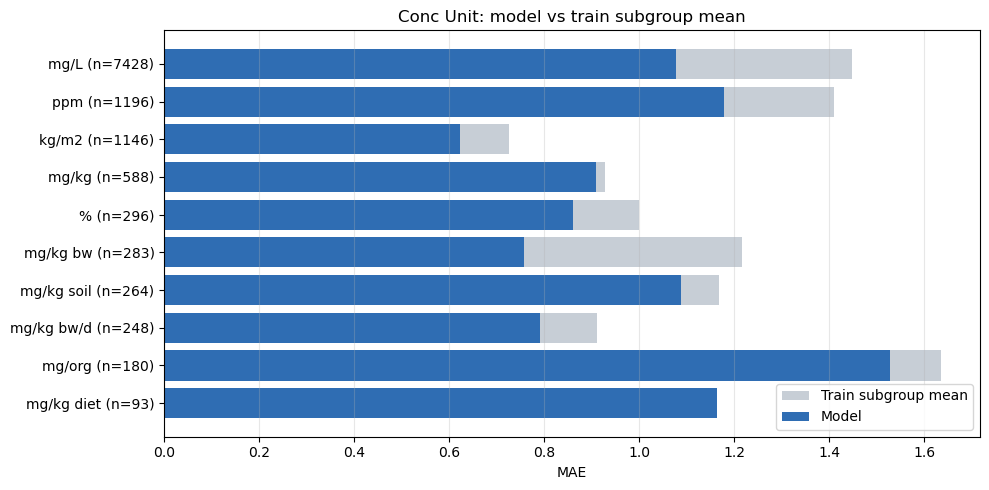

Species Group


,group,n,model_mae,baseline_mae,mae_gain
0,fish,2971,0.990945,1.366087,0.375141
1,insects,2028,1.110072,2.420554,1.310483
2,crustaceans,1925,1.093109,1.476114,0.383005
3,plants,940,0.889722,2.434438,1.544717
4,rodents,858,0.841496,1.091743,0.250248
5,algae,578,1.094265,1.359041,0.264776
6,worms,541,1.032237,1.507037,0.474800
7,mollusks,524,1.035490,1.292621,0.257131
8,amphibians,390,1.002962,1.221556,0.218594
9,birds,246,0.939013,1.386199,0.447186


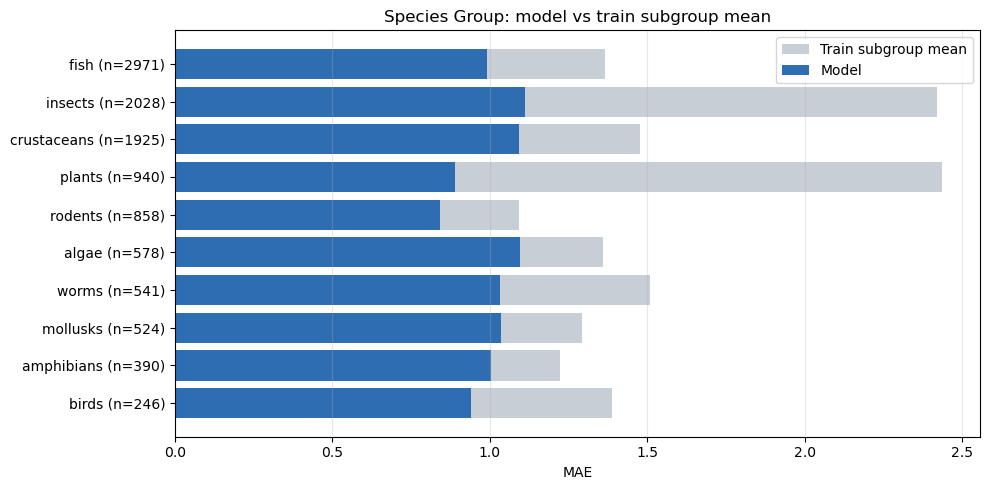

Endpoint


,group,n,model_mae,baseline_mae,mae_gain
0,EC50,6053,1.006880,1.752572,0.745692
1,NOEC,2993,1.071828,2.066955,0.995127
2,LOEC,2273,0.982264,2.170468,1.188204
3,EC10,459,1.164436,1.619173,0.454736


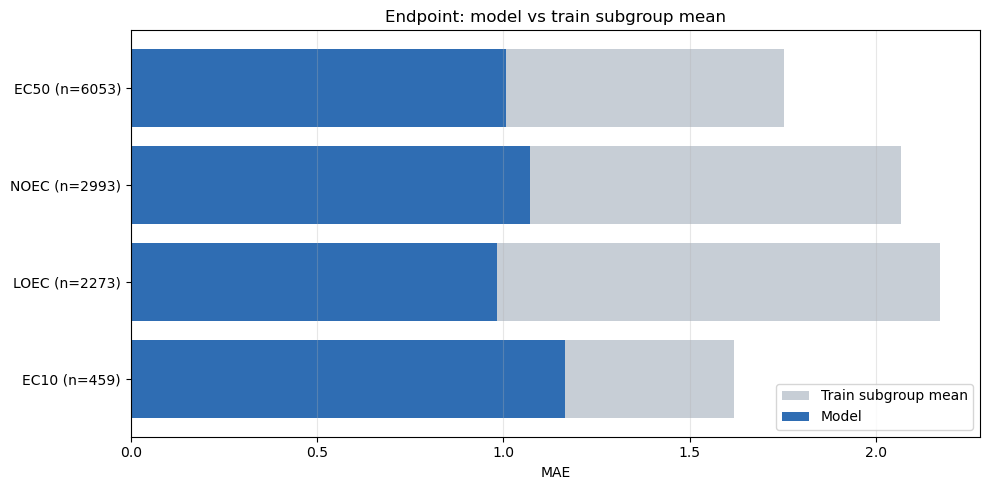

Effect


,group,n,model_mae,baseline_mae,mae_gain
0,MOR,5840,1.020728,1.803710,0.782982
1,POP,1655,0.835668,2.260713,1.425045
2,GRO,1226,1.091286,1.832644,0.741358
3,REP,884,1.047223,1.829971,0.782748
4,BEH,534,1.292054,2.544207,1.252153
5,PHY,425,1.207747,1.685446,0.477699
6,DVP,418,1.077360,1.845151,0.767791
7,MPH,405,1.030579,1.669032,0.638453
8,ITX,391,1.000199,1.555227,0.555028


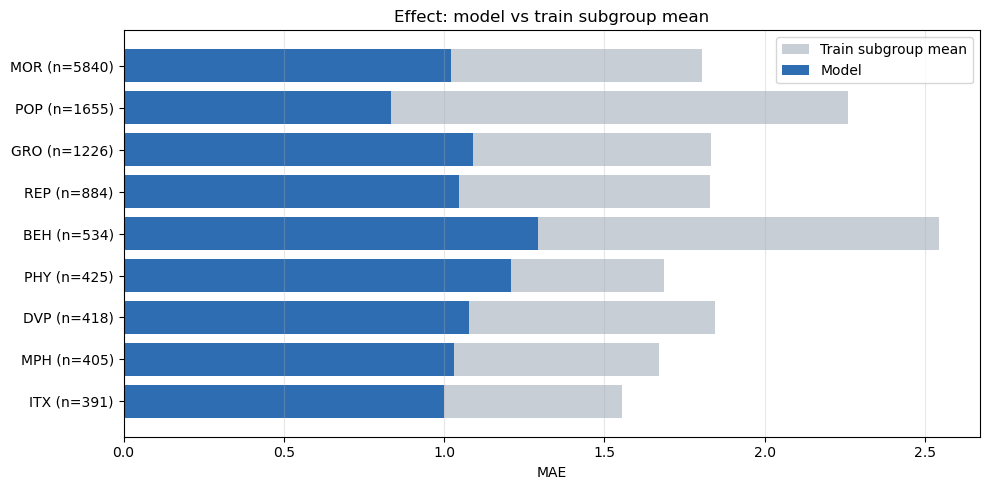

Fragment Bin


,group,n,model_mae,baseline_mae,mae_gain
0,1,9601,1.008929,1.931477,0.922548
1,2,1308,1.160414,1.599695,0.439281
2,3+,869,0.995679,1.489533,0.493854


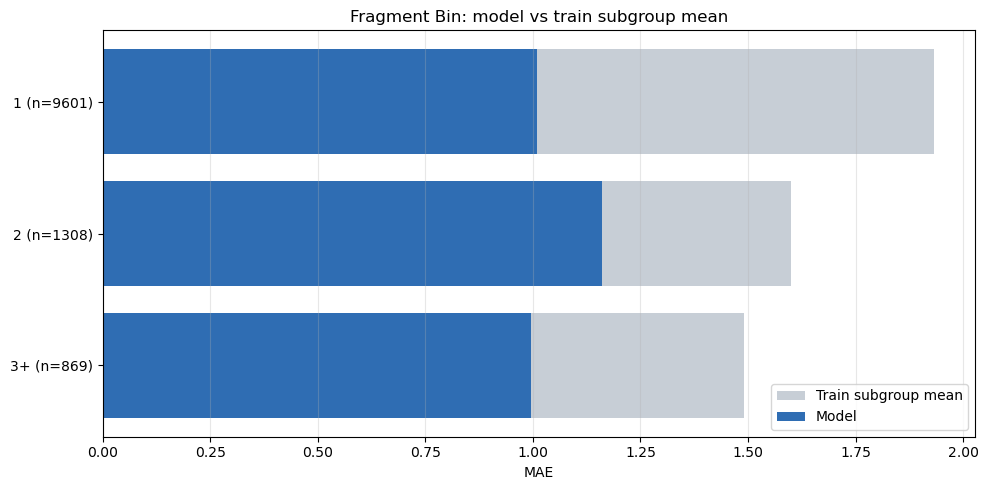

Has Metal Group


,group,n,model_mae,baseline_mae,mae_gain
0,No metal,9249,1.034982,2.018912,0.983930
1,Has metal,2529,0.987444,1.431029,0.443585


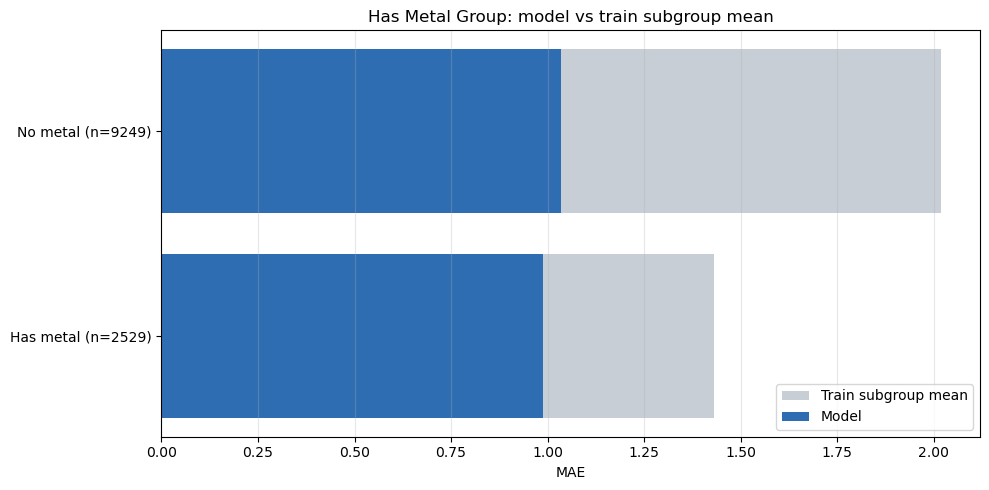

Top species with at least 20 test rows


,group,n,model_mae,baseline_mae,mae_gain
0,daphnia magna,733,1.047177,1.421810,0.374633
1,rattus norvegicus,520,0.784455,0.969988,0.185533
2,oncorhynchus mykiss,421,0.926435,1.252598,0.326162
3,pimephales promelas,345,0.923422,1.438843,0.515421
4,danio rerio,296,1.306734,1.656770,0.350036
5,mus musculus,273,0.890604,1.044222,0.153618
6,apis mellifera,192,1.501408,2.368085,0.866677
7,raphidocelis subcapitata,173,1.012481,1.392093,0.379612
8,lepomis macrochirus,155,0.927997,1.554149,0.626152
9,ceriodaphnia dubia,131,1.079552,1.516765,0.437213


Single-node support on the test set
is_single_group
Not single-node    11279
Single-node          499


In [30]:
group_cols = [
    "conc_unit",
    "species_group",
    "endpoint",
    "effect",
    "fragment_bin",
    "has_metal_group",
]

# train_df["actual_log10c"] = [g.y.item() * target_std + target_mean for g in train_dataset]
train_df["actual_log10c"] = [g.y.item() for g in train_dataset]

group_summaries = {}
for group_col in group_cols:
    title = group_col.replace("_", " ").title()
    summary = summarize_by_group(results_df, train_df, group_col, min_count=25)
    group_summaries[group_col] = summary

    print(title)
    display(summary[["group", "n", "model_mae", "baseline_mae", "mae_gain"]])
    plot_group_mae(summary, title=f"{title}: model vs train subgroup mean")

species_summary = summarize_by_group(results_df, train_df, "species_latin_name", min_count=20)
print("Top species with at least 20 test rows")
display(species_summary.head(15)[["group", "n", "model_mae", "baseline_mae", "mae_gain"]])

print("Single-node support on the test set")
print(results_df["is_single_group"].value_counts(dropna=False).to_string())

if wandb_run is not None:
    for group_col, summary in group_summaries.items():
        wandb_run.log({f"group_summary/{group_col}": wandb.Table(dataframe=summary)})
    wandb_run.log({"group_summary/species_latin_name": wandb.Table(dataframe=species_summary)})
    wandb_run.finish()
